# Цель проекта: 
### * Использование нейронных сетей глубокого обучения для классификации токсичных комментариев в социальных сетях
### * Создание ML приложения, для отображения работы нейронной модели в приложении
### * Создание базы данных, для сохранения комментария, его статуса

## Загрузка библиотек

In [1]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pymorphy3

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import string
import re
import nltk
import pymorphy3

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer


### Загрузка дата сета

In [4]:
df = pd.read_csv('labeled.csv')

#### Информация о столбцах
* comment - комментарии пользователей
* toxic - идентикатор токсичности комментария

In [5]:
df

,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0
2,Собаке - собачья смерть\n,1.0
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0
...,...,...
14407,Вонючий совковый скот прибежал и ноет. А вот и...,1.0
14408,А кого любить? Гоблина тупорылого что-ли? Или ...,1.0
14409,"Посмотрел Утомленных солнцем 2. И оказалось, ч...",0.0
14410,КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА Т.К В НЕМ Н...,1.0


### Отобразим общее количество где Toxic равен 0 и 1

In [6]:
# print("АНАЛИЗ ДАННЫХ")
# print("=" * 60)

# # Посмотрим на первые несколько строк
# print("\nПервые 5 строк данных:")
# print(df[['comment', 'toxic', 'Лемматизированный текст']].head())

# # Проверим распределение классов
# print("\nРаспределение классов (toxic):")
# print(df['toxic'].value_counts())
# print(f"\nДоля хороших комментариев (0): {df['toxic'].value_counts(normalize=True)[0]:.2%}")
# print(f"Доля плохих комментариев (1): {df['toxic'].value_counts(normalize=True)[1]:.2%}")

#### Отобразим хорошие комментарии

In [7]:
df[df['toxic'] == 0.0].head()

,comment,toxic
6,В шапке были ссылки на инфу по текущему фильму...,0.0
12,"Почитайте посты у этого автора,может найдете ч...",0.0
17,Про графику было обидно) я так то проходил все...,0.0
28,https: pp.userapi.com c848520 v848520411 11627...,0.0
35,"Возьмём как пример Россию, западноевропейские ...",0.0


## Предварительная обработка данных
- Перевод всех букв в тексте в нижний регистр
- Удаление знаков препинания
- Токенизация по словам
- Удаление стоп слов
- Стемминг (приведение слов к нормальной форме)
- Лемматизация

### Обработанный текст:

In [8]:
def remove_punctuation(text): 
    return "".join([ch if ch not in string.punctuation else ' ' for ch in text])

def remove_numbers(text): 
    return ''.join([i if not i.isdigit() else ' ' for i in text])

def remove_multiple_spaces(text): 
    return re.sub(r'\s+', ' ', text, flags=re.I)

st = '❯\xa0—«»'
def remove_othersymbol(text):
    return ''.join([ch if ch not in st else ' ' for ch in text])

def remove_english(text):
    return re.sub(r'[a-zA-Z]', '', text)

In [9]:
df['Обработанный комментарий'] = [remove_multiple_spaces(remove_numbers(remove_othersymbol(remove_punctuation(remove_english(text.lower()))))) for text in df['comment']]

### Результат преобразования текста

In [10]:
df['comment'][6]

'В шапке были ссылки на инфу по текущему фильму марвел. Эти ссылки были заменены на фразу Репортим брипидора, игнорируем его посты. Если этого недостаточно, чтобы понять, что модератор абсолютный неадекват, и его нужно лишить полномочий, тогда эта борда пробивает абсолютное дно по неадекватности.\n'

In [11]:
df['Обработанный комментарий'][6]

'в шапке были ссылки на инфу по текущему фильму марвел эти ссылки были заменены на фразу репортим брипидора игнорируем его посты если этого недостаточно чтобы понять что модератор абсолютный неадекват и его нужно лишить полномочий тогда эта борда пробивает абсолютное дно по неадекватности '

### ----------------------------------------------------------------------------------------------------

In [12]:
russian_stopwords = stopwords.words("russian")

In [13]:
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    text = " ".join(tokens)
    return text

In [14]:
df['Токенизированный текст'] = [tokenize(text) for text in df['Обработанный комментарий']]

In [15]:
df

,comment,toxic,Обработанный комментарий,Токенизированный текст
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0,верблюдов то за что дебилы бл,верблюдов дебилы бл
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0,хохлы это отдушина затюканого россиянина мол в...,хохлы это отдушина затюканого россиянина мол в...
2,Собаке - собачья смерть\n,1.0,собаке собачья смерть,собаке собачья смерть
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0,страницу обнови дебил это тоже не оскорбление ...,страницу обнови дебил это оскорбление доказанн...
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0,тебя не убедил страничный пдф в том что скрипа...,убедил страничный пдф скрипалей отравила росси...
...,...,...,...,...
14407,Вонючий совковый скот прибежал и ноет. А вот и...,1.0,вонючий совковый скот прибежал и ноет а вот и ...,вонючий совковый скот прибежал ноет сторонник ...
14408,А кого любить? Гоблина тупорылого что-ли? Или ...,1.0,а кого любить гоблина тупорылого что ли или ка...,кого любить гоблина тупорылого какую продажную...
14409,"Посмотрел Утомленных солнцем 2. И оказалось, ч...",0.0,посмотрел утомленных солнцем и оказалось что э...,посмотрел утомленных солнцем оказалось это хор...
14410,КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА Т.К В НЕМ Н...,1.0,крымотред нарушает правила раздела т к в нем н...,крымотред нарушает правила раздела т нем обсуж...


In [16]:
df['Токенизированный текст'][6]

'шапке ссылки инфу текущему фильму марвел ссылки заменены фразу репортим брипидора игнорируем посты недостаточно понять модератор абсолютный неадекват нужно лишить полномочий эта борда пробивает абсолютное дно неадекватности'

## Просматор на часто используемые слова в комметариях

In [17]:
stemmer = SnowballStemmer("russian")

stem_list = []
for text in (df['Токенизированный текст']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = stemmer.stem(word)
            res.append(p)
        text = " ".join(res)
        stem_list.append(text)
    except Exception as e:
        print(e)
        
df['Стеммингированный текст'] = stem_list

In [18]:
df

,comment,toxic,Обработанный комментарий,Токенизированный текст,Стеммингированный текст
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0,верблюдов то за что дебилы бл,верблюдов дебилы бл,верблюд дебил бл
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0,хохлы это отдушина затюканого россиянина мол в...,хохлы это отдушина затюканого россиянина мол в...,хохл эт отдушин затюкан россиянин мол вон хохл...
2,Собаке - собачья смерть\n,1.0,собаке собачья смерть,собаке собачья смерть,собак собач смерт
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0,страницу обнови дебил это тоже не оскорбление ...,страницу обнови дебил это оскорбление доказанн...,страниц обнов деб эт оскорблен доказа факт деб...
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0,тебя не убедил страничный пдф в том что скрипа...,убедил страничный пдф скрипалей отравила росси...,убед страничн пдф скрипал отрав росс анализиро...
...,...,...,...,...,...
14407,Вонючий совковый скот прибежал и ноет. А вот и...,1.0,вонючий совковый скот прибежал и ноет а вот и ...,вонючий совковый скот прибежал ноет сторонник ...,вонюч совков скот прибежа ноет сторонник демок...
14408,А кого любить? Гоблина тупорылого что-ли? Или ...,1.0,а кого любить гоблина тупорылого что ли или ка...,кого любить гоблина тупорылого какую продажную...,ког люб гоблин тупорыл как продажн сук демшиз ...
14409,"Посмотрел Утомленных солнцем 2. И оказалось, ч...",0.0,посмотрел утомленных солнцем и оказалось что э...,посмотрел утомленных солнцем оказалось это хор...,посмотрел утомлен солнц оказа эт хорош фильм т...
14410,КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА Т.К В НЕМ Н...,1.0,крымотред нарушает правила раздела т к в нем н...,крымотред нарушает правила раздела т нем обсуж...,крымотред наруша прав раздел т нем обсужден по...


# Сделаем обработку текста с нашим датесетом

In [19]:
morph = pymorphy3.MorphAnalyzer(lang='ru')

In [20]:
%%time
lemm_texts_list = []
for text in (df['Токенизированный текст']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = morph.parse(word)[0]
            res.append(p.normal_form)
        text = " ".join(res)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df['Лемматизированный текст'] = lemm_texts_list

CPU times: total: 58.4 s
Wall time: 1min 1s


In [21]:
df["Лемматизированный текст"][6]

'шапка ссылка инф текущий фильм марвести ссылка заменить фраза репортить брипидор игнорировать пост недостаточно понять модератор абсолютный неадекват нужно лишить полномочие этот борд пробивать абсолютный дно неадекватность'

In [22]:
df.head(5)

,comment,toxic,Обработанный комментарий,Токенизированный текст,Стеммингированный текст,Лемматизированный текст
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0,верблюдов то за что дебилы бл,верблюдов дебилы бл,верблюд дебил бл,верблюд дебил бл
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0,хохлы это отдушина затюканого россиянина мол в...,хохлы это отдушина затюканого россиянина мол в...,хохл эт отдушин затюкан россиянин мол вон хохл...,хохол это отдушина затюканый россиянин мол вон...
2,Собаке - собачья смерть\n,1.0,собаке собачья смерть,собаке собачья смерть,собак собач смерт,собака собачий смерть
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0,страницу обнови дебил это тоже не оскорбление ...,страницу обнови дебил это оскорбление доказанн...,страниц обнов деб эт оскорблен доказа факт деб...,страница обновить дебил это оскорбление доказа...
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0,тебя не убедил страничный пдф в том что скрипа...,убедил страничный пдф скрипалей отравила росси...,убед страничн пдф скрипал отрав росс анализиро...,убедить страничный пдф скрипаль отравить росси...


In [23]:
stemmer = SnowballStemmer("russian")

stem_list = []
for text in (df['Токенизированный текст']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = stemmer.stem(word)
            res.append(p)
        text = " ".join(res)
        stem_list.append(text)
    except Exception as e:
        print(e)
        
df['Стеммингированный текст'] = stem_list

In [24]:
df["Стеммингированный текст"][6]

'шапк ссылк инф текущ фильм марвел ссылк замен фраз репорт брипидор игнориру пост недостаточн поня модератор абсолютн неадекват нужн лиш полномоч эт борд пробива абсолютн дно неадекватн'

In [25]:
df.head(5)

,comment,toxic,Обработанный комментарий,Токенизированный текст,Стеммингированный текст,Лемматизированный текст
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0,верблюдов то за что дебилы бл,верблюдов дебилы бл,верблюд дебил бл,верблюд дебил бл
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0,хохлы это отдушина затюканого россиянина мол в...,хохлы это отдушина затюканого россиянина мол в...,хохл эт отдушин затюкан россиянин мол вон хохл...,хохол это отдушина затюканый россиянин мол вон...
2,Собаке - собачья смерть\n,1.0,собаке собачья смерть,собаке собачья смерть,собак собач смерт,собака собачий смерть
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0,страницу обнови дебил это тоже не оскорбление ...,страницу обнови дебил это оскорбление доказанн...,страниц обнов деб эт оскорблен доказа факт деб...,страница обновить дебил это оскорбление доказа...
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0,тебя не убедил страничный пдф в том что скрипа...,убедил страничный пдф скрипалей отравила росси...,убед страничн пдф скрипал отрав росс анализиро...,убедить страничный пдф скрипаль отравить росси...


In [26]:
morph = pymorphy3.MorphAnalyzer(lang='ru')

In [27]:
%%time
lemm_texts_list = []
for text in (df['Токенизированный текст']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = morph.parse(word)[0]
            res.append(p.normal_form)
        text = " ".join(res)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df['Лемматизированный текст'] = lemm_texts_list

CPU times: total: 57.6 s
Wall time: 59.8 s


In [28]:
df['Лемматизированный текст'][6]

'шапка ссылка инф текущий фильм марвести ссылка заменить фраза репортить брипидор игнорировать пост недостаточно понять модератор абсолютный неадекват нужно лишить полномочие этот борд пробивать абсолютный дно неадекватность'

In [29]:
df.head(5)

,comment,toxic,Обработанный комментарий,Токенизированный текст,Стеммингированный текст,Лемматизированный текст
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0,верблюдов то за что дебилы бл,верблюдов дебилы бл,верблюд дебил бл,верблюд дебил бл
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0,хохлы это отдушина затюканого россиянина мол в...,хохлы это отдушина затюканого россиянина мол в...,хохл эт отдушин затюкан россиянин мол вон хохл...,хохол это отдушина затюканый россиянин мол вон...
2,Собаке - собачья смерть\n,1.0,собаке собачья смерть,собаке собачья смерть,собак собач смерт,собака собачий смерть
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0,страницу обнови дебил это тоже не оскорбление ...,страницу обнови дебил это оскорбление доказанн...,страниц обнов деб эт оскорблен доказа факт деб...,страница обновить дебил это оскорбление доказа...
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0,тебя не убедил страничный пдф в том что скрипа...,убедил страничный пдф скрипалей отравила росси...,убед страничн пдф скрипал отрав росс анализиро...,убедить страничный пдф скрипаль отравить росси...


# Облако слов

In [30]:
pip install WordCloud

Note: you may need to restart the kernel to use updated packages.


In [31]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
%matplotlib inline

In [32]:
# Получение текстовой строки из списка слов
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus

# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus

# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

In [33]:
non_toxic_df = df[df['toxic'] == 0]
corpus = get_corpus(non_toxic_df['comment'].values)
procWordCloud = get_wordCloud(corpus)

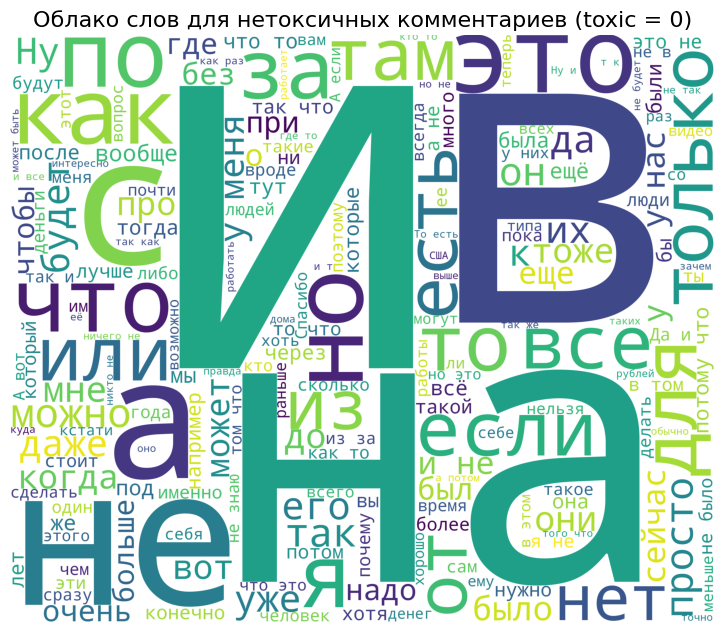

In [34]:
fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.title('Облако слов для нетоксичных комментариев (toxic = 0)', fontsize=16)
plt.show()

### Облако слов лемматизированного текста

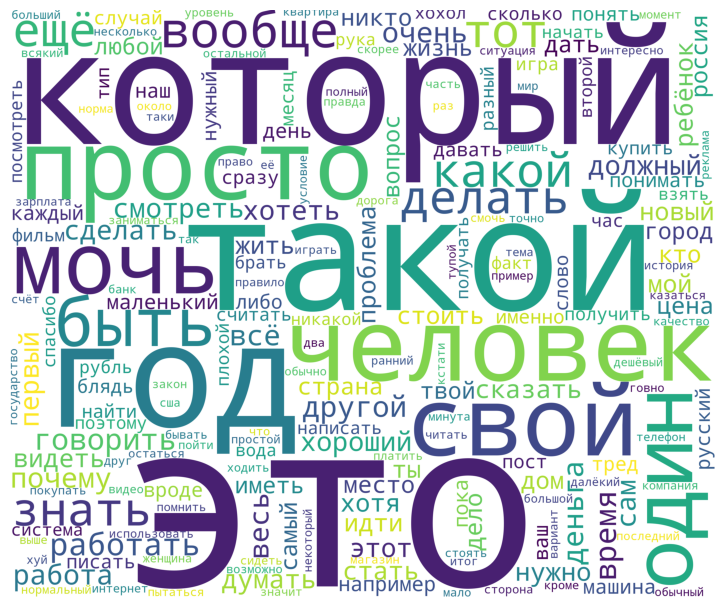

In [35]:
non_toxic_df = df[df['toxic'] == 0.0]
no_toxic_corpus = get_corpus(df['Лемматизированный текст'].values)
procWordCloud = get_wordCloud(no_toxic_corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.show()

# Векторизация текстовых данных

In [36]:
from sklearn.feature_extraction.text import CountVectorizer

In [37]:
vectorizer = CountVectorizer()
vectorizer.fit(df['Лемматизированный текст'])

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [38]:
print(vectorizer.vocabulary_)

{'верблюд': 2719, 'дебил': 5698, 'бл': 1693, 'хохол': 30539, 'это': 32144, 'отдушина': 17281, 'затюканый': 8403, 'россиянин': 24216, 'мол': 13515, 'вон': 3471, 'хохлов': 30503, 'плохой': 19214, 'кисель': 10232, 'придумать': 21473, 'собака': 25938, 'собачий': 25940, 'смерть': 25801, 'страница': 27011, 'обновить': 16095, 'оскорбление': 17067, 'доказать': 6426, 'факт': 29584, 'множественный': 13437, 'число': 31132, 'писать': 19015, 'верить': 2727, 'твой': 27637, 'воображать': 3478, 'друг': 6824, 'убедить': 28644, 'страничный': 27012, 'пдф': 18165, 'скрипаль': 25559, 'отравить': 17507, 'россия': 24214, 'анализировать': 540, 'думать': 6882, 'пытаться': 22798, 'ватник': 2521, 'какой': 9677, 'стан': 26773, 'являться': 32264, 'эталон': 32123, 'современный': 26034, 'система': 25348, 'здравоохранение': 8577, 'рф': 24409, 'зимбабве': 8633, 'тупой': 28484, 'шапка': 31339, 'ссылка': 26727, 'инф': 9316, 'текущий': 27674, 'фильм': 29803, 'марвести': 12677, 'заменить': 8005, 'фраза': 29973, 'репортить

In [39]:
vectorizer = CountVectorizer(analyzer='word', stop_words=russian_stopwords, ngram_range=(1, 3), min_df=2)
count_matrix = vectorizer.fit_transform(df['Лемматизированный текст'])

In [40]:
count_matrix.shape

(14412, 35084)

In [41]:
vectorizer.get_feature_names_out()[1000:1500]

array(['бельё', 'бенз', 'бензин', 'бентли', 'бентли заниматься',
       'бентли заниматься благотворительность', 'бер', 'берег',
       'беременная', 'беременность', 'беременный', 'берет', 'берлога',
       'берлога старость', 'берлога старость увести', 'берухо', 'берцы',
       'берёза', 'бес', 'беседа', 'бесить', 'бесить проявление',
       'бесить проявление агрессия', 'бесить собака',
       'бесить собака бесить', 'беситься', 'бескаркасный', 'бесклассовый',
       'бесклассовый общество', 'бесклассовый общество борьба',
       'бесконечно', 'бесконечно долго', 'бесконечность', 'бесконечный',
       'бесконечный суть', 'бесконечный суть убить', 'бесплатно',
       'бесплатно месяц', 'бесплатно месяц забывать',
       'бесплатно необходимость', 'бесплатно необходимость переплачивать',
       'бесплатно это', 'бесплатный', 'бесплатный вроде',
       'бесплатный диагностика', 'бесплатный медицина',
       'бесплатный сохранять', 'бесплатный сохранять файл',
       'бесплатный сыр', 'б

In [42]:
df

,comment,toxic,Обработанный комментарий,Токенизированный текст,Стеммингированный текст,Лемматизированный текст
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0,верблюдов то за что дебилы бл,верблюдов дебилы бл,верблюд дебил бл,верблюд дебил бл
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0,хохлы это отдушина затюканого россиянина мол в...,хохлы это отдушина затюканого россиянина мол в...,хохл эт отдушин затюкан россиянин мол вон хохл...,хохол это отдушина затюканый россиянин мол вон...
2,Собаке - собачья смерть\n,1.0,собаке собачья смерть,собаке собачья смерть,собак собач смерт,собака собачий смерть
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0,страницу обнови дебил это тоже не оскорбление ...,страницу обнови дебил это оскорбление доказанн...,страниц обнов деб эт оскорблен доказа факт деб...,страница обновить дебил это оскорбление доказа...
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0,тебя не убедил страничный пдф в том что скрипа...,убедил страничный пдф скрипалей отравила росси...,убед страничн пдф скрипал отрав росс анализиро...,убедить страничный пдф скрипаль отравить росси...
...,...,...,...,...,...,...
14407,Вонючий совковый скот прибежал и ноет. А вот и...,1.0,вонючий совковый скот прибежал и ноет а вот и ...,вонючий совковый скот прибежал ноет сторонник ...,вонюч совков скот прибежа ноет сторонник демок...,вонючий совковый скот прибежать ныть сторонник...
14408,А кого любить? Гоблина тупорылого что-ли? Или ...,1.0,а кого любить гоблина тупорылого что ли или ка...,кого любить гоблина тупорылого какую продажную...,ког люб гоблин тупорыл как продажн сук демшиз ...,кто любить гоблин тупорылый какой продажный су...
14409,"Посмотрел Утомленных солнцем 2. И оказалось, ч...",0.0,посмотрел утомленных солнцем и оказалось что э...,посмотрел утомленных солнцем оказалось это хор...,посмотрел утомлен солнц оказа эт хорош фильм т...,посмотреть утомлённый солнце оказаться это хор...
14410,КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА Т.К В НЕМ Н...,1.0,крымотред нарушает правила раздела т к в нем н...,крымотред нарушает правила раздела т нем обсуж...,крымотред наруша прав раздел т нем обсужден по...,крымотред нарушать правило раздел так немой об...


# Добавляем библиотеки

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Матрица признаков:

In [191]:
# Преобразуем тексты в матрицу признаков
X = tfidf_vectorizer.fit_transform(df['Лемматизированный текст']).toarray()
y = df['toxic'].values

print(f"Размер матрицы признаков: {X.shape}")
print(f"Количество признаков: {X.shape[1]}")

Размер матрицы признаков: (14412, 1000)
Количество признаков: 1000


In [192]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,  # 20% на тест
    random_state=42,
    stratify=y  # сохраняем пропорции классов
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"\nРаспределение в обучающей выборке:")
print(pd.Series(y_train).value_counts())
print(f"\nРаспределение в тестовой выборке:")
print(pd.Series(y_test).value_counts())

Обучающая выборка: (11529, 1000)
Тестовая выборка: (2883, 1000)

Распределение в обучающей выборке:
0.0    7668
1.0    3861
Name: count, dtype: int64

Распределение в тестовой выборке:
0.0    1918
1.0     965
Name: count, dtype: int64


# Обучение модели LogisticRegression

In [46]:
from sklearn.linear_model import LogisticRegression

In [47]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',  # автоматически учитывает дисбаланс классов
    C=1.0,  # параметр регуляризации
    solver='liblinear'  # хорошо работает с разреженными матрицами
)

In [48]:
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [49]:
print("\n" + "=" * 60)
print("ПРЕДСКАЗАНИЯ НА ТЕСТОВЫХ ДАННЫХ")
print("=" * 60)

# Предсказания классов
y_pred = lr_model.predict(X_test)
print("✓ Предсказания классов получены")

# Предсказания вероятностей
y_pred_proba = lr_model.predict_proba(X_test)
print("✓ Вероятности классов получены")

# Вероятности для класса 1 (плохие комментарии)
y_pred_proba_1 = y_pred_proba[:, 1]


ПРЕДСКАЗАНИЯ НА ТЕСТОВЫХ ДАННЫХ
✓ Предсказания классов получены
✓ Вероятности классов получены


In [50]:
# Accuracy (точность)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy (общая точность): {accuracy:.4f}")

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba_1)
print(f"ROC-AUC: {roc_auc:.4f}")

# Детальный отчет по классам
print("\nClassification Report:")
print("-" * 50)
print(classification_report(y_test, y_pred, 
                           target_names=['Хорошие (0.0)', 'Плохие (1.0)']))


Accuracy (общая точность): 0.8685
ROC-AUC: 0.9166

Classification Report:
--------------------------------------------------
               precision    recall  f1-score   support

Хорошие (0.0)       0.90      0.90      0.90      1918
 Плохие (1.0)       0.80      0.81      0.80       965

     accuracy                           0.87      2883
    macro avg       0.85      0.85      0.85      2883
 weighted avg       0.87      0.87      0.87      2883



### Матрица ошибок

In [51]:
cm_rf = confusion_matrix(y_test, y_pred)

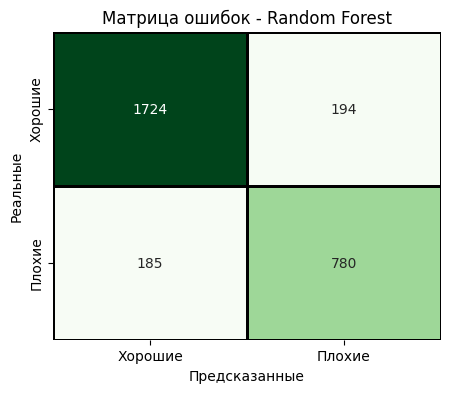

In [52]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, 
            annot=True, 
            fmt='d',
            xticklabels=['Хорошие', 'Плохие'],
            yticklabels=['Хорошие', 'Плохие'],
            cmap='Greens',  # зеленый для Random Forest (можно оставить Blues)
            cbar=False,
            linewidths=1,
            linecolor='black')
plt.title('Матрица ошибок - Random Forest', fontsize=12)
plt.xlabel('Предсказанные', fontsize=10)
plt.ylabel('Реальные', fontsize=10)
plt.show()

# Обучение модели: Random Forest 

### Загружаем библиотеки

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
# Создаем и обучаем модель
rf_model = RandomForestClassifier(
    n_estimators=100,      # количество деревьев
    max_depth=10,           # максимальная глубина дерева
    random_state=42,        # для воспроизводимости
    class_weight='balanced', # учитываем дисбаланс классов
    n_jobs=-1               # используем все ядра процессора
)

In [55]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [56]:
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [57]:
accuracy = accuracy_score(y_test, y_pred_rf)
roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

In [58]:
print("\n📌 Classification Report:")
print("-" * 40)
print(classification_report(y_test, y_pred_rf, 
                           target_names=['Хорошие', 'Плохие']))


📌 Classification Report:
----------------------------------------
              precision    recall  f1-score   support

     Хорошие       0.90      0.72      0.80      1918
      Плохие       0.60      0.84      0.70       965

    accuracy                           0.76      2883
   macro avg       0.75      0.78      0.75      2883
weighted avg       0.80      0.76      0.76      2883



In [59]:
cm = confusion_matrix(y_test, y_pred_rf)

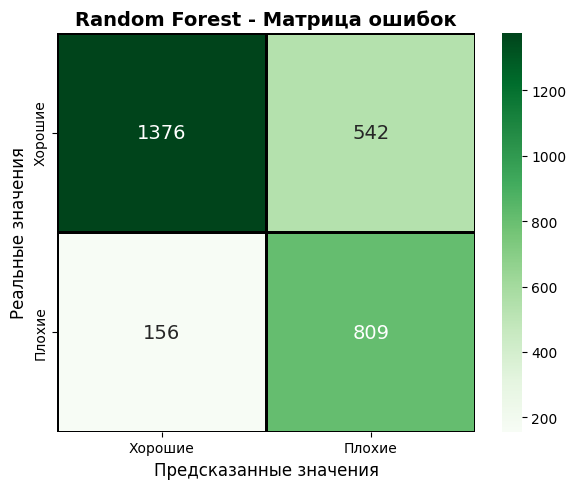

In [60]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            xticklabels=['Хорошие', 'Плохие'],
            yticklabels=['Хорошие', 'Плохие'],
            cmap='Greens',
            cbar=True,
            linewidths=1,
            linecolor='black',
            annot_kws={'size': 14})

plt.title('Random Forest - Матрица ошибок', fontsize=14, fontweight='bold')
plt.xlabel('Предсказанные значения', fontsize=12)
plt.ylabel('Реальные значения', fontsize=12)
plt.tight_layout()
plt.show()

# Обучение модели: KNN

### Загружаем библиотеку 

In [61]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

In [62]:
k_values = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
accuracies = []
auc_scores = []
models = []  # сохраняем модели для каждого K

for k in k_values:
    # Создаем модель KNN
    knn_model = KNeighborsClassifier(
        n_neighbors=k,
        weights='distance',      # взвешивание по расстоянию
        metric='cosine',         # косинусная метрика для текстов
        n_jobs=-1                # используем все ядра
    )
    knn_model.fit(X_train, y_train)
    models.append(knn_model)  # сохраняем модель

In [63]:
y_pred = knn_model.predict(X_test)
y_proba = knn_model.predict_proba(X_test)[:, 1]

In [64]:
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
        
accuracies.append(acc)
auc_scores.append(auc)
    
print(f"K={k}: Accuracy={acc:.4f}, ROC-AUC={auc:.4f}")

K=21: Accuracy=0.7964, ROC-AUC=0.8444


In [65]:
best_k_idx = np.argmax(auc_scores)
best_k = k_values[best_k_idx]
best_acc = accuracies[best_k_idx]
best_auc = auc_scores[best_k_idx]

In [66]:
# Обучаем финальную модель с лучшим K
knn_final = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',      
    metric='cosine',         
    n_jobs=-1
)
knn_final.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [67]:
y_pred_knn = knn_final.predict(X_test)
y_proba_knn = knn_final.predict_proba(X_test)[:, 1]

In [68]:
accuracy = accuracy_score(y_test, y_pred_knn)
roc_auc = roc_auc_score(y_test, y_proba_knn)

print(f"\n📊 Финальная модель (K={best_k}):")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   ROC-AUC: {roc_auc:.4f}")


📊 Финальная модель (K=3):
   Accuracy: 0.7655
   ROC-AUC: 0.7875


In [69]:
from sklearn.metrics import classification_report

print("\n📌 Classification Report для KNN:")
print("-" * 50)
print(classification_report(y_test, y_pred_knn, 
                           target_names=['Хорошие', 'Плохие']))


📌 Classification Report для KNN:
--------------------------------------------------
              precision    recall  f1-score   support

     Хорошие       0.81      0.84      0.83      1918
      Плохие       0.66      0.61      0.63       965

    accuracy                           0.77      2883
   macro avg       0.74      0.73      0.73      2883
weighted avg       0.76      0.77      0.76      2883



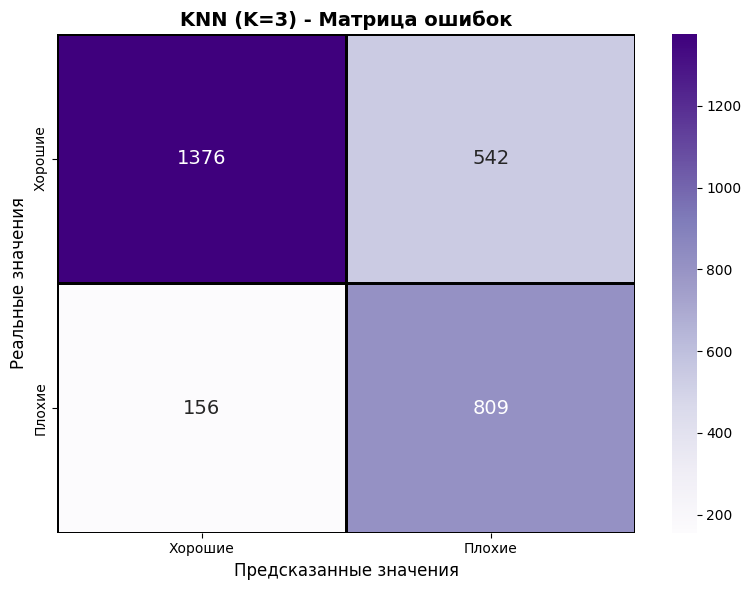

In [70]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            xticklabels=['Хорошие', 'Плохие'],
            yticklabels=['Хорошие', 'Плохие'],
            cmap='Purples',  # фиолетовый для KNN
            cbar=True,
            linewidths=1,
            linecolor='black',
            annot_kws={'size': 14})

plt.title(f'KNN (K={best_k}) - Матрица ошибок', fontsize=14, fontweight='bold')
plt.xlabel('Предсказанные значения', fontsize=12)
plt.ylabel('Реальные значения', fontsize=12)
plt.tight_layout()
plt.show()

# Обучение нейронной модели - основная цель проекта

In [159]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 192977 stored elements and shape (11529, 35084)>

In [121]:
X_train.shape

(11529, 35084)

In [122]:
y_train.shape

(11529,)

In [193]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import InputLayer, Dense
from sklearn.preprocessing import StandardScaler

In [244]:

# model = tf.keras.Sequential([
#     Dense(64, activation='leaky_relu'),
#     Dense(32, activation='leaky_relu'),
#     Dense(1, activation='sigmoid')
# ])

# Постороение модели
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(300,), name='input_layer'),
    tf.keras.layers.Embedding(30000, 300, name='embedding'),
    tf.keras.layers.LSTM(50, return_sequences=True, name='lstm'),
    tf.keras.layers.GlobalMaxPooling1D(name='global_max_pooling_1d'),
    tf.keras.layers.Dropout(0.4, name='dropout_1'),
    tf.keras.layers.Dense(100, activation='leaky_relu', name='dense_1'),
    tf.keras.layers.Dropout(0.4, name='dropout_2'),
    tf.keras.layers.Dense(1, activation='sigmoid', name='dense_2')
])

# class_weight = {0: 1.0, 1: 9.0}

model.compile(optimizer='adam', 
              # loss='binary_crossentropy', 
              loss=tf.keras.losses.binary_crossentropy, 
              metrics=['accuracy'])

In [245]:

print(model.summary())

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 300)       │     9,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 300, 50)        │        70,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling_1d           │ (None, 50)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,075,401 (34.62 MB)

 Trainable params: 9,075,401 (34.62 MB)

 Non-trainable params: 0 (0.00 B)

None


In [246]:
y_train

array([0., 0., 1., ..., 1., 1., 0.])

In [247]:
model.fit(X_train, y_train, 
                    epochs=4)

Epoch 1/4
361/361 ━━━━━━━━━━━━━━━━━━━━ 17177s 48s/step - accuracy: 0.6630 - loss: 0.6400
Epoch 2/4
361/361 ━━━━━━━━━━━━━━━━━━━━ 142s 394ms/step - accuracy: 0.6662 - loss: 0.6343
Epoch 3/4
361/361 ━━━━━━━━━━━━━━━━━━━━ 211s 420ms/step - accuracy: 0.6668 - loss: 0.6333
Epoch 4/4
361/361 ━━━━━━━━━━━━━━━━━━━━ 167s 462ms/step - accuracy: 0.6631 - loss: 0.6332


In [248]:
predictions = model.predict(X_test)

91/91 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step


In [249]:
predictions

array([[0.32384697],
       [0.32384697],
       [0.32384697],
       ...,
       [0.32384697],
       [0.32384697],
       [0.32384697]], dtype=float32)

In [250]:
y_pred = np.argmax(predictions, axis=1)

In [251]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [252]:
predicted_classes = (predictions > 0.5).astype(int)

In [253]:
print(classification_report(
    y_test,           # правильные метки
    predicted_classes,    # предсказанные классы
    labels=[0, 1], 
    target_names=['Хорошие', 'Плохие']
))

              precision    recall  f1-score   support

     Хорошие       0.67      1.00      0.80      1918
      Плохие       0.00      0.00      0.00       965

    accuracy                           0.67      2883
   macro avg       0.33      0.50      0.40      2883
weighted avg       0.44      0.67      0.53      2883



C:\Users\rusla\anaconda3\envs\testTenserIntel\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rusla\anaconda3\envs\testTenserIntel\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rusla\anaconda3\envs\testTenserIntel\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

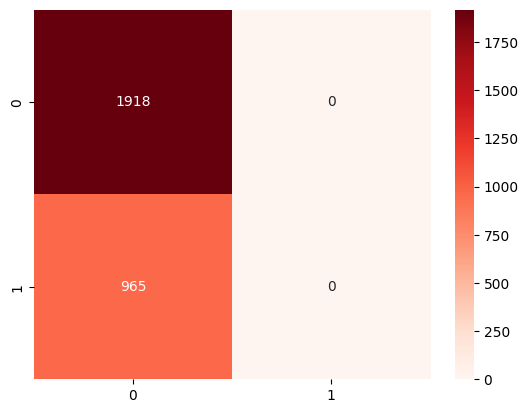

In [254]:
conf_matrix = confusion_matrix(y_test, predicted_classes)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.show()

#### Сохранение нейронных сетей, и модель

In [ ]:
import pickle
import joblib
from tensorflow.keras import models
import tempfile
import os

# Сохраняем
def save_all(model, vectorizer, filename='complete_model.pkl'):
    # Временное сохранение Keras модели
    model.save('_temp_keras.keras')
    
    with open('_temp_keras.keras', 'rb') as f:
        model_bytes = f.read()
    
    # Пакет для сохранения
    package = {
        'model': model_bytes,
        'vectorizer': vectorizer,
        'input_shape': model.input_shape[1]
    }
    
    # Сохраняем через pickle (работает везде)
    with open(filename, 'wb') as f:
        pickle.dump(package, f)
    
    os.remove('_temp_keras.keras')
    print(f"✅ Сохранено в {filename}")

# Загружаем
def load_all(filename='complete_model.pkl'):
    with open(filename, 'rb') as f:
        package = pickle.load(f)
    
    # Восстанавливаем модель
    with tempfile.NamedTemporaryFile(suffix='.keras', delete=False) as tf:
        tf.write(package['model'])
        temp_path = tf.name
    
    model = models.load_model(temp_path)
    os.remove(temp_path)
    
    return model, package['vectorizer'], package['input_shape']

# Используем
save_all(model, vectorizer_1000, 'my_complete_model.pkl')
m, v, shape = load_all('my_complete_model.pkl')
print(f"Модель загружена! Входной размер: {shape}")

# Вывод

### Что было проделано ?
- Мы прсомотрели дата сет на плохие и хорошие комментарии
- Мы произвел обработку текста, для обучение моделей\Нейронной сети
- Обучили модели и нейронную сеть. Все они показали хороший результат. Но основная поставленная задача это Нейронная сеть
- Сохранили модель нейронных сетей, для дальнейшего его использование в ML приложение

### Нейронная модель

- Отобразила не плохие результаты, я думаю если ещё дополнить датасет, поиграться с данными, можно получить модель немного лучше

#### Работу вы можете просмотреть на моём гите: 
- Vimer15/machine_learning/tree/main/22P-1%202_Semester/Russian%20Language%20Toxic%20Comments


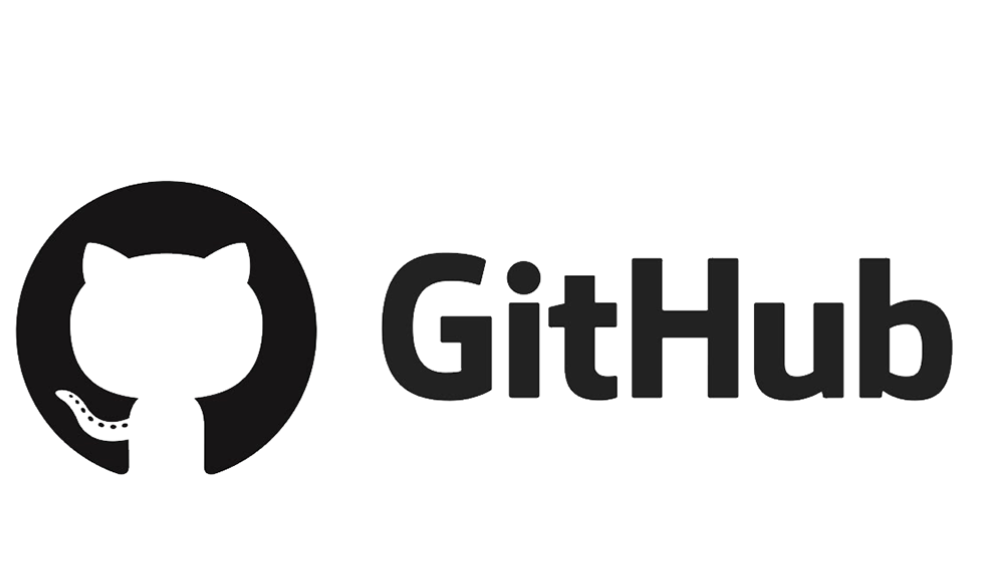